---
## **1. PERSIAPAN LINGKUNGAN**
Bagian ini memastikan semua kebutuhan sistem tersedia sebelum proses pelatihan dimulai.

### 1.1 Cek GPU
Memverifikasi bahwa Google Colab menggunakan GPU.

In [ ]:
!nvidia-smi

Sun Apr 19 14:18:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 1.2 Instalasi Library
Menginstal semua library eksternal yang dibutuhkan.

In [ ]:
!pip install ultralytics -q
!pip install -U albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.7 MB/s eta 0:00:00


### 1.3 Import Library
Memuat semua modul Python yang akan digunakan sepanjang notebook.

In [ ]:
import ultralytics
from ultralytics import YOLO

import os
import yaml
import random
import shutil
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import pandas as pd

from google.colab import files, drive

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### 1.4 Cek Environment Ultralytics
Memverifikasi versi, CUDA, dan semua dependensi ultralytics berjalan normal.

In [ ]:
ultralytics.checks()

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 43.0/235.7 GB disk)


### 1.5 Mount Google Drive
Menghubungkan Google Drive ke lingkungan Colab agar dataset dan model dapat diakses/disimpan secara persisten.

In [ ]:
drive.mount('/content/drive/')

Mounted at /content/drive/


---
## **2. PERSIAPAN DATASET**
Memuat dataset dari Google Drive, mengekstraksi, dan mendefinisikan path konfigurasi.

### 2.1 Load dan Ekstrak Dataset

In [ ]:
!unzip -q /content/drive/MyDrive/Dataset_Project_Padi/dataset/dataset.zip -d /content/dataset

replace /content/dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


### 2.2 Set Path Konfigurasi

In [ ]:
path_yaml = '/content/dataset/data.yaml'
print(f"Path YAML: {path_yaml}")
print(f"File ditemukan: {os.path.exists(path_yaml)}")

Path YAML: /content/dataset/data.yaml
File ditemukan: True


---
## **3. EKSPLORASI DAN VALIDASI DATASET**
Menganalisis distribusi kelas untuk memastikan dataset layak dilatih sebelum memulai training.


LAPORAN DISTRIBUSI DATASET
 ID Kelas         Nama Kelas  Train  Valid  Test  Total  Persentase (%)
        0     bercak_cokelat    659     82    82    823           19.68
        1               blas    618     85    58    761           18.20
        2   hama_putih_palsu    763    102    94    959           22.93
        3 hawar_daun_bakteri    620     90    80    790           18.89
        4              sehat    686     75    88    849           20.30
-------------------------------------------------------

EVALUASI KELAYAKAN DATASET
JUMLAH    : OK (Minimal 618 sampel).
KESEIMBANGAN: OK (Rasio 1:1.2).
VALIDASI  : Semua kelas punya data validasi.
-------------------------------------------------------
KESIMPULAN: DATASET SIAP DILATIH!


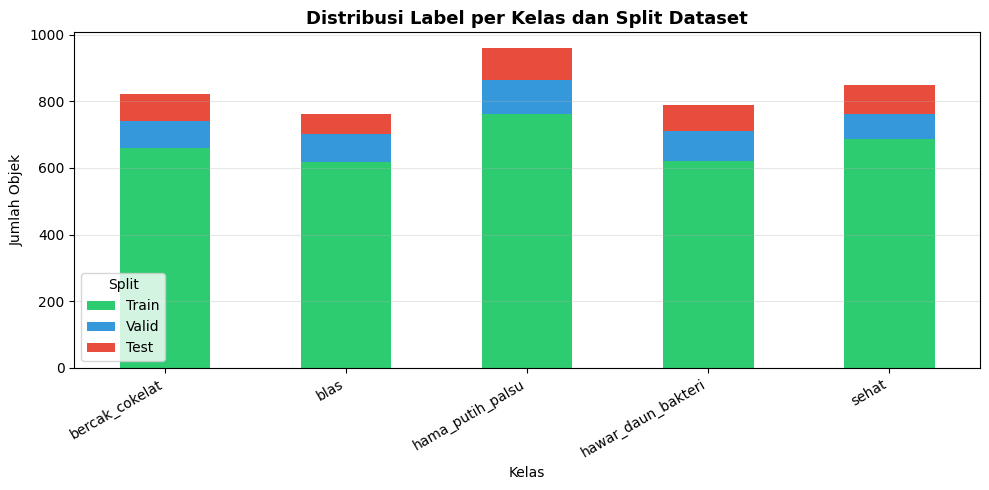

In [ ]:
try:
    # --- TAHAP 1: Baca file konfigurasi YAML ---
    with open(path_yaml, 'r') as f:
        data_info = yaml.safe_load(f)
        class_names = data_info['names']

    # --- TAHAP 2: Fungsi penghitung label per split ---
    def count_labels(split):
        """
        Menghitung jumlah objek per kelas pada split dataset tertentu.
        Format anotasi YOLO: setiap baris dalam .txt berisi [class_id, x, y, w, h]
        """
        label_path = f'/content/dataset/{split}/labels'
        counts = {i: 0 for i in range(len(class_names))}

        if not os.path.exists(label_path):
            return counts

        for file in os.listdir(label_path):
            if file.endswith('.txt'):
                with open(os.path.join(label_path, file), 'r') as f:
                    for line in f:
                        if line.strip():
                            try:
                                class_id = int(line.split()[0])
                                if class_id in counts:
                                    counts[class_id] += 1
                            except ValueError:
                                continue
        return counts

    # --- TAHAP 3: Hitung distribusi untuk setiap split ---
    train_dist = count_labels('train')
    val_dist   = count_labels('valid')
    test_dist  = count_labels('test')

    # --- TAHAP 4: Susun hasil ke dalam DataFrame ---
    df_dist = pd.DataFrame({
        'ID Kelas'     : list(train_dist.keys()),
        'Nama Kelas'   : class_names,
        'Train'        : list(train_dist.values()),
        'Valid'        : list(val_dist.values()),
        'Test'         : list(test_dist.values())
    })
    df_dist['Total']         = df_dist['Train'] + df_dist['Valid'] + df_dist['Test']
    df_dist['Persentase (%)'] = ((df_dist['Total'] / df_dist['Total'].sum()) * 100).round(2)

    # --- TAHAP 5: Tampilkan tabel distribusi ---
    print("\n" + "="*55)
    print("LAPORAN DISTRIBUSI DATASET")
    print("="*55)
    print(df_dist.to_string(index=False))
    print("-" * 55)

    # --- TAHAP 6: Evaluasi kelayakan dataset ---
    print("\nEVALUASI KELAYAKAN DATASET")

    min_train       = df_dist['Train'].min()
    max_train       = df_dist['Train'].max()
    min_class       = df_dist.loc[df_dist['Train'].idxmin(), 'Nama Kelas']
    imbalance_ratio = max_train / (min_train if min_train > 0 else 1)
    is_safe         = True

    # Cek jumlah data minimal
    if min_train < 100:
        print(f"KRITIS    : Kelas '{min_class}' hanya {min_train} sampel. Tambah data!")
        is_safe = False
    elif min_train < 250:
        print(f"PERINGATAN: Jumlah minimal ({min_train}) rendah. Hasil mungkin kurang stabil.")
    else:
        print(f"JUMLAH    : OK (Minimal {min_train} sampel).")

    # Cek ketimpangan antar kelas
    if imbalance_ratio > 10:
        print(f"KRITIS    : Ketimpangan ekstrem 1:{imbalance_ratio:.1f}. Model akan sangat bias!")
        is_safe = False
    elif imbalance_ratio > 4:
        print(f"PERINGATAN: Rasio 1:{imbalance_ratio:.1f}. Pertimbangkan augmentasi kelas minoritas.")
    else:
        print(f"KESEIMBANGAN: OK (Rasio 1:{imbalance_ratio:.1f}).")

    # Cek apakah ada kelas tanpa data validasi
    if (df_dist['Valid'] == 0).any():
        print("KRITIS    : Ada kelas yang TIDAK memiliki data validasi!")
        is_safe = False
    else:
        print("VALIDASI  : Semua kelas punya data validasi.")

    print("-" * 55)
    if is_safe:
        print("KESIMPULAN: DATASET SIAP DILATIH!")
    else:
        print("KESIMPULAN: DATASET BUTUH PERBAIKAN SEBELUM TRAINING.")
    print("="*55)

    # --- TAHAP 7: Visualisasi distribusi label ---
    df_dist.set_index('Nama Kelas')[['Train', 'Valid', 'Test']].plot(
        kind='bar', stacked=True, figsize=(10, 5),
        color=['#2ecc71', '#3498db', '#e74c3c']
    )
    plt.title('Distribusi Label per Kelas dan Split Dataset', fontsize=13, fontweight='bold')
    plt.ylabel('Jumlah Objek')
    plt.xlabel('Kelas')
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.legend(title='Split')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Terjadi kesalahan: {e}")

---
## **4. PELATIHAN MODEL YOLOv8**
Melatih model YOLOv8 versi 4 kelas (tanpa kelas Bercak Cokelat).

**Arsitektur:** YOLOv8m (medium) — keseimbangan terbaik antara akurasi dan kecepatan inferensi.

### 4.1 Definisi Kelas yang Dilatih

In [ ]:
kelas_yang_dilatih = [1, 2, 3, 4]
print(f"Kelas yang dilatih: {kelas_yang_dilatih}")

Kelas yang dilatih: [1, 2, 3, 4]


### 4.2 Load Pretrained Model

In [ ]:
model = YOLO('yolov8m.pt')
print("Model YOLOv8m berhasil dimuat.")

Model YOLOv8m berhasil dimuat.


### 4.3 Training Model 4 Kelas

In [ ]:
results = model.train(
    data      = path_yaml,
    epochs    = 300,
    imgsz     = 640,
    batch     = 64,
    plots     = True,
    patience  = 50,
    name      = 'train_project_TA_padi_empat_kelas',

    optimizer = 'AdamW',
    cos_lr    = True,
    lr0       = 0.001,
    lrf       = 0.01,

    mosaic    = 1.0,
    mixup     = 0.1,
    degrees   = 5.0,
    hsv_s     = 0.5,
    hsv_v     = 0.4,
    flipud    = 0.0,
    fliplr    = 0.5,

    classes = kelas_yang_dilatih
)

print("\nTraining selesai!")
print(f"Hasil tersimpan di: runs/detect/train_project_TA_padi_empat_kelas/")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=[1, 2, 3, 4], close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_project_TA_padi_empat_kelas, nbs=64, nms=False, opset=None, optimize=False, optimizer=Ada

---
## **5. EVALUASI HASIL TRAINING**
Memvisualisasikan dan menganalisis metrik performa model setelah pelatihan selesai.

### 5.1 Cek File Hasil Training

In [ ]:
base_path = 'runs/detect/train_project_TA_padi_empat_kelas/'

# Verifikasi folder hasil tersedia
if os.path.exists(base_path):
    print(f"Folder berhasil ditemukan: {base_path}")
    print("\nIsi folder:")
    !ls '{base_path}'
else:
    print(f"Folder tidak ditemukan. Pastikan training sudah selesai.")

Folder berhasil ditemukan: runs/detect/train_project_TA_padi_empat_kelas/

Isi folder:
args.yaml			 confusion_matrix.png  train_batch2.jpg
BoxF1_curve.png			 labels.jpg	       val_batch0_labels.jpg
BoxP_curve.png			 results.csv	       val_batch0_pred.jpg
BoxPR_curve.png			 results.png	       val_batch1_labels.jpg
BoxR_curve.png			 train_batch0.jpg      val_batch1_pred.jpg
confusion_matrix_normalized.png  train_batch1.jpg      weights


### 5.2 Visualisasi Metrik Evaluasi

In [ ]:
# Fungsi bantu untuk membaca gambar dari disk ke format array NumPy
def load_img(path):
    """Membaca gambar dari path dan mengembalikan array NumPy."""
    return mpimg.imread(path)

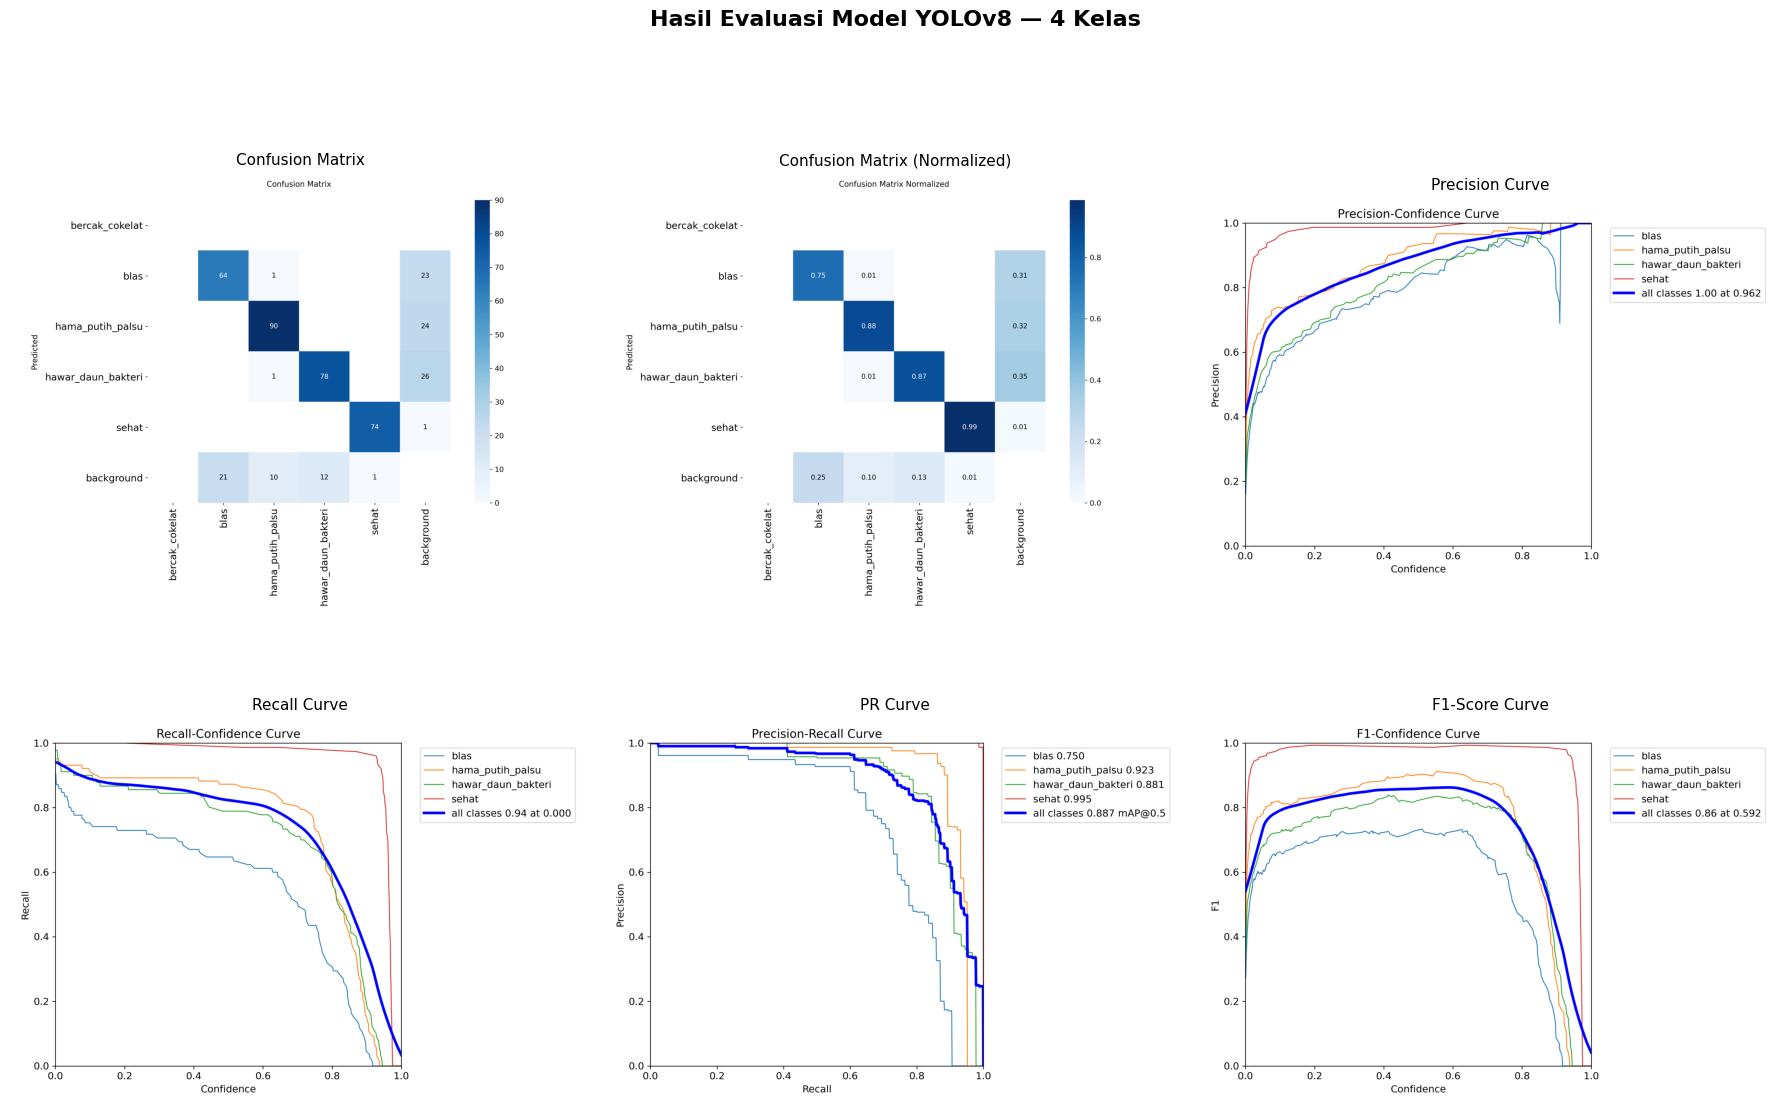

In [ ]:
# Daftar grafik evaluasi yang dihasilkan otomatis oleh ultralytics (plots=True)
images = [
    ("Confusion Matrix",            'confusion_matrix.png'),
    ("Confusion Matrix (Normalized)",'confusion_matrix_normalized.png'),
    ("Precision Curve",             'BoxP_curve.png'),
    ("Recall Curve",                'BoxR_curve.png'),
    ("PR Curve",                    'BoxPR_curve.png'),
    ("F1-Score Curve",              'BoxF1_curve.png'),
]

# Tampilkan semua grafik dalam satu figure (2 baris × 3 kolom)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Hasil Evaluasi Model YOLOv8 — 4 Kelas",
             fontsize=16, fontweight='bold', y=1.02)

for ax, (title, file) in zip(axes.flatten(), images):
    img_path = base_path + file
    if os.path.exists(img_path):
        ax.imshow(load_img(img_path))
        ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f'File tidak ditemukan:\n{file}',
                ha='center', va='center', transform=ax.transAxes, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 5.3 Kurva Training (Loss & mAP)

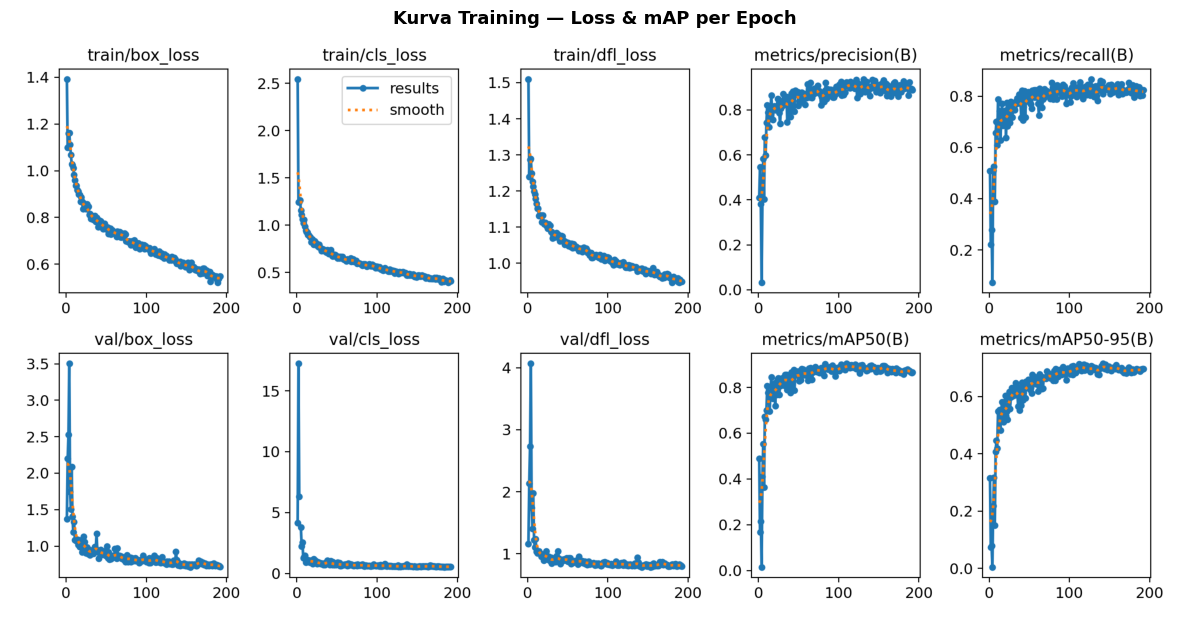

In [ ]:
results_img_path = base_path + 'results.png'
if os.path.exists(results_img_path):
    plt.figure(figsize=(12, 7))
    plt.imshow(load_img(results_img_path))
    plt.title("Kurva Training — Loss & mAP per Epoch", fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"File results.png tidak ditemukan di {base_path}")

### 5.4 Visualisasi Prediksi pada Data Validasi

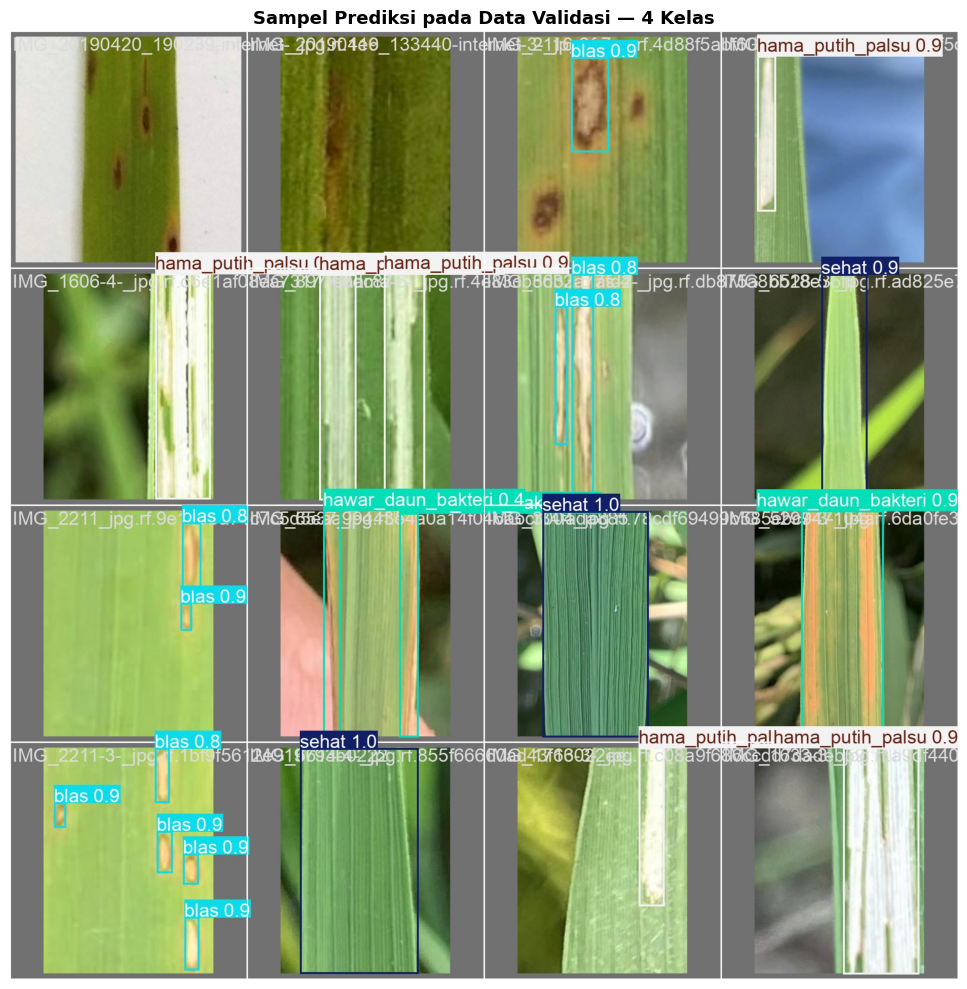

In [ ]:
val_img_path = base_path + 'val_batch0_pred.jpg'
if os.path.exists(val_img_path):
    plt.figure(figsize=(14, 10))
    plt.imshow(load_img(val_img_path))
    plt.title("Sampel Prediksi pada Data Validasi — 4 Kelas", fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"File val_batch0_pred.jpg tidak ditemukan.")

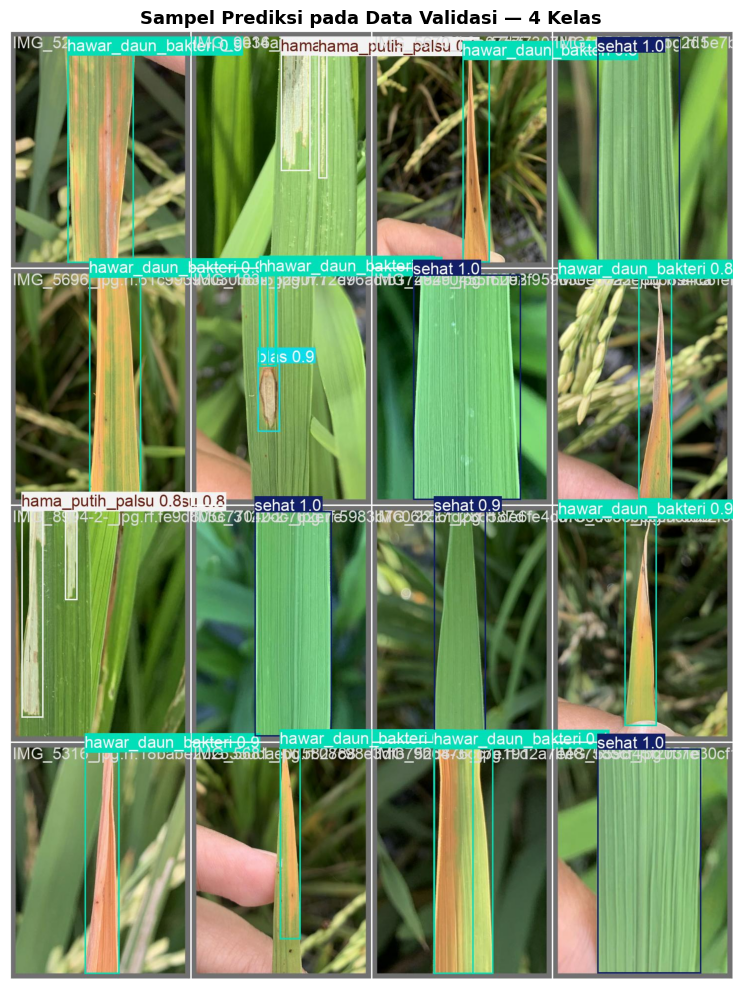

In [ ]:
.val_img_path = base_path + 'val_batch1_pred.jpg'
if os.path.exists(val_img_path):
    plt.figure(figsize=(14, 10))
    plt.imshow(load_img(val_img_path))
    plt.title("Sampel Prediksi pada Data Validasi — 4 Kelas", fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"File val_batch1_pred.jpg tidak ditemukan.")

### 5.5 Kalkulasi Metrik dari results.csv

METRIK MODEL (EPOCH TERBAIK)
  Epoch Terbaik   : 110
  Precision       : 0.9218
  Recall          : 0.8158
  F1-Score        : 0.8656
  mAP@50          : 0.9043
  mAP@50-95       : 0.7025


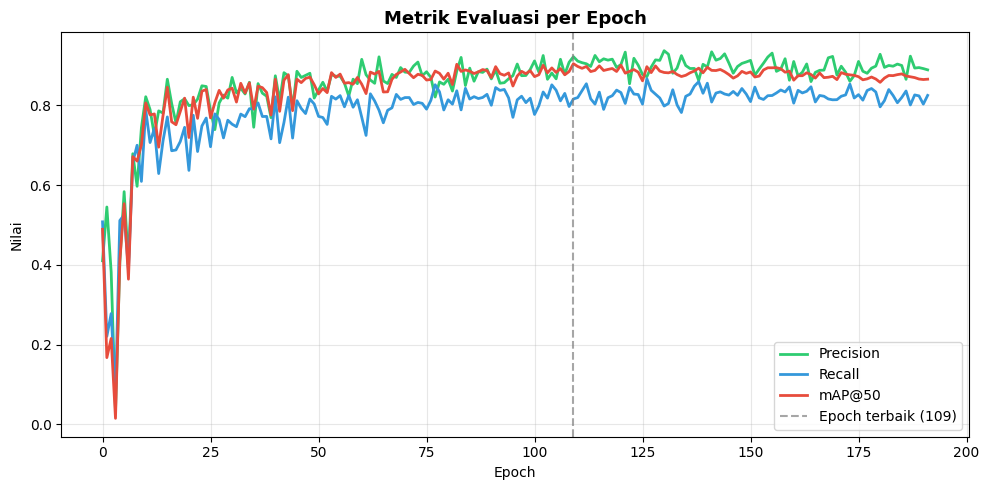

In [ ]:
csv_path = base_path + 'results.csv'

if os.path.exists(csv_path):
    df_results = pd.read_csv(csv_path)

    df_results.columns = df_results.columns.str.strip()

    # Ambil baris epoch terbaik berdasarkan mAP50
    best_idx = df_results['metrics/mAP50(B)'].idxmax()
    best_row = df_results.loc[best_idx]

    precision = best_row['metrics/precision(B)']
    recall    = best_row['metrics/recall(B)']
    mAP50     = best_row['metrics/mAP50(B)']
    mAP5095   = best_row['metrics/mAP50-95(B)']

    # Hitung F1-Score: harmonic mean dari precision dan recall
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print("=" * 45)
    print("METRIK MODEL (EPOCH TERBAIK)")
    print("=" * 45)
    print(f"  Epoch Terbaik   : {int(best_row.get('epoch', best_idx))}")
    print(f"  Precision       : {precision:.4f}")
    print(f"  Recall          : {recall:.4f}")
    print(f"  F1-Score        : {f1:.4f}")
    print(f"  mAP@50          : {mAP50:.4f}")
    print(f"  mAP@50-95       : {mAP5095:.4f}")
    print("=" * 45)

    # Visualisasi Precision & Recall per epoch
    plt.figure(figsize=(10, 5))
    plt.plot(df_results['metrics/precision(B)'], label='Precision', color='#2ecc71', linewidth=2)
    plt.plot(df_results['metrics/recall(B)'],    label='Recall',    color='#3498db', linewidth=2)
    plt.plot(df_results['metrics/mAP50(B)'],     label='mAP@50',   color='#e74c3c', linewidth=2)
    plt.axvline(x=best_idx, color='gray', linestyle='--', alpha=0.7, label=f'Epoch terbaik ({best_idx})')
    plt.title('Metrik Evaluasi per Epoch', fontsize=13, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Nilai')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"File results.csv tidak ditemukan di {base_path}")

---
## **6. INFERENSI**
Menguji performa model terlatih pada data baru yang belum pernah dilihat sebelumnya.

### 6.1 Inferensi Batch pada Test Set

In [ ]:
model_terbaik = YOLO(base_path + 'weights/best.pt')

# Jalankan prediksi pada seluruh test set
hasil_test = model_terbaik.predict(
    source = '/content/dataset/test/images',
    conf   = 0.15,
    save   = False
)

# Susun semua hasil deteksi ke dalam list of dict
data_deteksi = []

for r in hasil_test:
    nama_file = os.path.basename(r.path)

    for box in r.boxes:
        cls   = int(box.cls[0])
        conf  = float(box.conf[0])
        label = r.names[cls]
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        data_deteksi.append({
            "Nama File" : nama_file,
            "Kelas"     : label,
            "Confidence": round(conf, 3),
            "x1": int(x1), "y1": int(y1),
            "x2": int(x2), "y2": int(y2)
        })

# Buat DataFrame hasil deteksi
df_deteksi = pd.DataFrame(data_deteksi)
print(f"Total objek terdeteksi: {len(df_deteksi)}")
df_deteksi.head(10)


image 1/246 /content/dataset/test/images/IMG_1032_jpg.rf.216373ff89a23cb9fc5d2d9e14cedf23.jpg: 640x480 4 hama_putih_palsus, 10.0ms
image 2/246 /content/dataset/test/images/IMG_1037-2-_jpg.rf.018e03d34b12c5f282e5e91846ed4319.jpg: 640x480 2 hama_putih_palsus, 9.8ms
image 3/246 /content/dataset/test/images/IMG_1038-2-_jpg.rf.228e6c3f861eea35856f19bc24ad3f8c.jpg: 640x480 1 sehat, 8.9ms
image 4/246 /content/dataset/test/images/IMG_1040-2-_jpg.rf.e3686da61e8049a4659161181892a71d.jpg: 640x480 4 hama_putih_palsus, 8.7ms
image 5/246 /content/dataset/test/images/IMG_1065-2-_jpg.rf.a481fa301004360397f2c3b54e8ede1b.jpg: 640x480 1 hawar_daun_bakteri, 8.8ms
image 6/246 /content/dataset/test/images/IMG_1069_jpg.rf.61307eba79340dfe6a289ebc91a1a6ec.jpg: 640x480 3 hama_putih_palsus, 9.0ms
image 7/246 /content/dataset/test/images/IMG_1073_jpg.rf.3915f32f1ea1045c074df38a95820964.jpg: 640x480 1 hama_putih_palsu, 9.3ms
image 8/246 /content/dataset/test/images/IMG_1077-3-_jpg.rf.16408094dc94dcfe7517a34bc587

,Nama File,Kelas,Confidence,x1,y1,x2,y2
0,IMG_1032_jpg.rf.216373ff89a23cb9fc5d2d9e14cedf...,hama_putih_palsu,0.701,597,1,693,926
1,IMG_1032_jpg.rf.216373ff89a23cb9fc5d2d9e14cedf...,hama_putih_palsu,0.618,669,79,852,2225
2,IMG_1032_jpg.rf.216373ff89a23cb9fc5d2d9e14cedf...,hama_putih_palsu,0.577,588,1002,716,2230
3,IMG_1032_jpg.rf.216373ff89a23cb9fc5d2d9e14cedf...,hama_putih_palsu,0.414,693,783,821,2182
4,IMG_1037-2-_jpg.rf.018e03d34b12c5f282e5e91846e...,hama_putih_palsu,0.923,116,161,189,266
5,IMG_1037-2-_jpg.rf.018e03d34b12c5f282e5e91846e...,hama_putih_palsu,0.158,115,166,151,265
6,IMG_1038-2-_jpg.rf.228e6c3f861eea35856f19bc24a...,sehat,0.925,187,0,528,904
7,IMG_1040-2-_jpg.rf.e3686da61e8049a465916118189...,hama_putih_palsu,0.768,316,0,462,840
8,IMG_1040-2-_jpg.rf.e3686da61e8049a465916118189...,hama_putih_palsu,0.743,97,0,216,837
9,IMG_1040-2-_jpg.rf.e3686da61e8049a465916118189...,hama_putih_palsu,0.700,112,466,201,820


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_deteksi)

https://docs.google.com/spreadsheets/d/1UUZk1OUlOVMu0F5gqPCPeiaOLJCIOX6H4RDPH4pH5qs/edit#gid=0


In [ ]:
# Ringkasan jumlah deteksi per file dan per kelas
summary_deteksi = df_deteksi.groupby(["Nama File", "Kelas"]).size().reset_index(name="Jumlah Deteksi")
print(f"Ringkasan deteksi per file ({len(summary_deteksi)} entri):")
summary_deteksi.head(20)

Ringkasan deteksi per file (254 entri):


,Nama File,Kelas,Jumlah Deteksi
0,IMG_1032_jpg.rf.216373ff89a23cb9fc5d2d9e14cedf...,hama_putih_palsu,4
1,IMG_1037-2-_jpg.rf.018e03d34b12c5f282e5e91846e...,hama_putih_palsu,2
2,IMG_1038-2-_jpg.rf.228e6c3f861eea35856f19bc24a...,sehat,1
3,IMG_1040-2-_jpg.rf.e3686da61e8049a465916118189...,hama_putih_palsu,4
4,IMG_1065-2-_jpg.rf.a481fa301004360397f2c3b54e8...,hawar_daun_bakteri,1
5,IMG_1069_jpg.rf.61307eba79340dfe6a289ebc91a1a6...,hama_putih_palsu,3
6,IMG_1073_jpg.rf.3915f32f1ea1045c074df38a958209...,hama_putih_palsu,1
7,IMG_1077-3-_jpg.rf.16408094dc94dcfe7517a34bc58...,sehat,1
8,IMG_1089-3-_jpg.rf.87634ca51716061414ba16da537...,sehat,1
9,IMG_1094_jpg.rf.12a4a5b6504225fa47c72b7dc9e9af...,hama_putih_palsu,1


In [ ]:
# Ekspor hasil deteksi ke file CSV
nama_csv = 'hasil_deteksi_project_TA_padi_empat_kelas.csv'
df_deteksi.to_csv(nama_csv, index=False)
files.download(nama_csv)
print(f"File '{nama_csv}' berhasil diunduh.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File 'hasil_deteksi_project_TA_padi_empat_kelas.csv' berhasil diunduh.



Menampilkan 5 sampel hasil prediksi dari test set



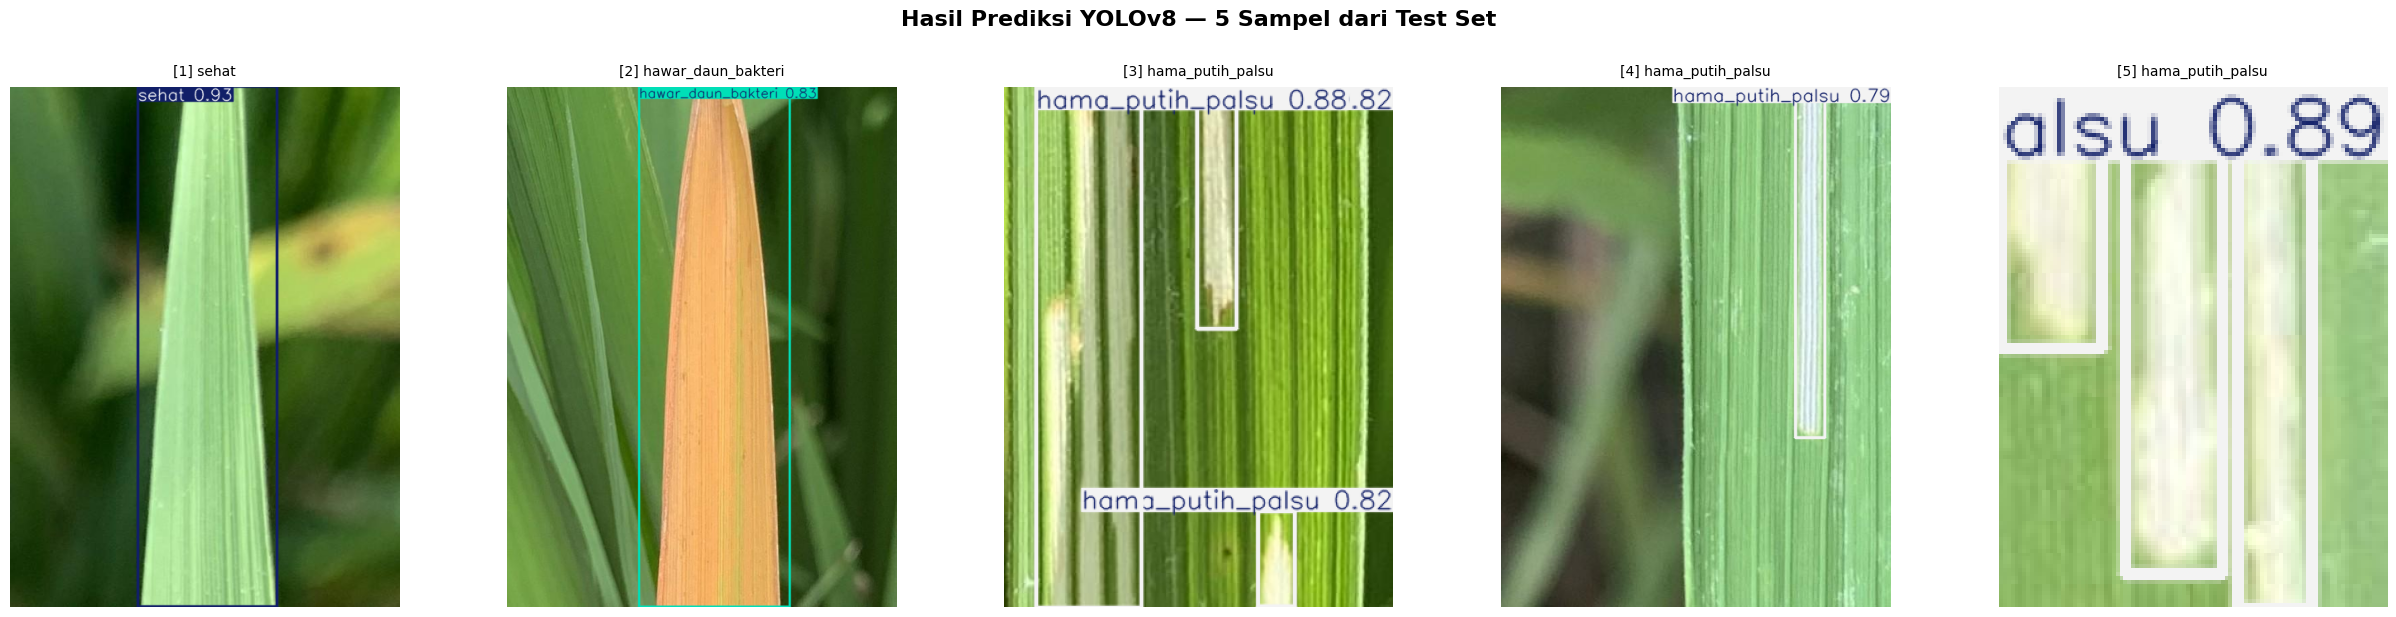

Selesai menampilkan 5 gambar hasil prediksi.


In [ ]:
print("\nMenampilkan 5 sampel hasil prediksi dari test set\n")

test_img_folder = '/content/dataset/test/images'
semua_gambar    = [f for f in os.listdir(test_img_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

gambar_sample   = random.sample(semua_gambar, min(5, len(semua_gambar)))

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
fig.suptitle("Hasil Prediksi YOLOv8 — 5 Sampel dari Test Set", fontsize=16, fontweight='bold', y=1.02)

for i, nama_gambar in enumerate(gambar_sample):
    path_gambar = os.path.join(test_img_folder, nama_gambar)

    hasil = model_terbaik.predict(
        source  = path_gambar,
        conf    = 0.15,
        save    = False,
        verbose = False
    )

    annotated_img     = hasil[0].plot()
    annotated_img_rgb = annotated_img[:, :, ::-1]

    if len(hasil[0].boxes) == 0:
        judul = f"[{i+1}] Tidak ada deteksi"
    else:
        label_list = [hasil[0].names[int(b.cls[0])] for b in hasil[0].boxes]
        label_unik = list(dict.fromkeys(label_list))
        judul      = f"[{i+1}] {', '.join(label_unik)}"

    axes[i].imshow(annotated_img_rgb)
    axes[i].set_title(judul, fontsize=10, pad=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Selesai menampilkan 4 gambar hasil prediksi.")

### 6.2 Uji Coba Gambar Baru (Single Image Prediction)

Menganalisis gambar: IMG_9193.jpg

Results saved to /content/runs/detect/predict


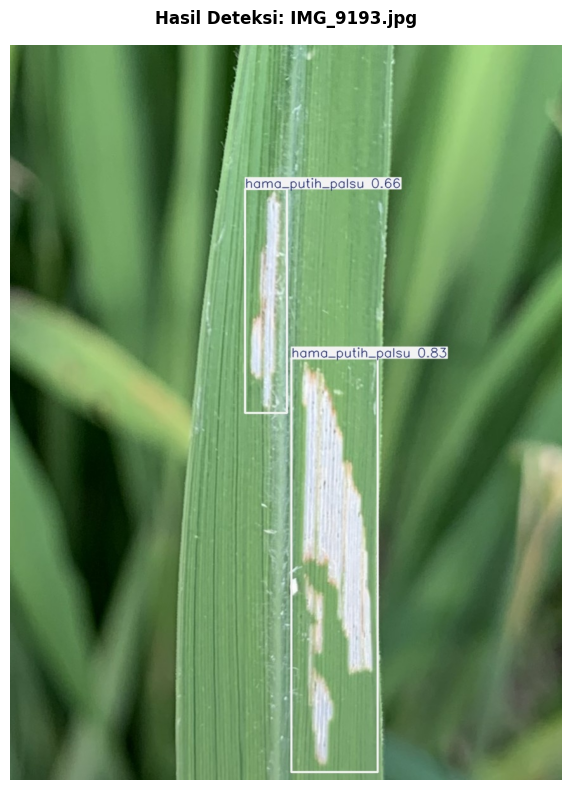


 Laporan Hasil Deteksi:
----------------------------------------
hama_putih_palsu          (Confidence: 83.36%)
hama_putih_palsu          (Confidence: 66.17%)


In [ ]:
gambar_tes = 'IMG_9193.jpg'

if not os.path.exists(gambar_tes):
    print(f"File '{gambar_tes}' tidak ditemukan di /content/")
    print("Upload file gambar terlebih dahulu, lalu jalankan ulang cell ini.")
else:
    print(f"Menganalisis gambar: {gambar_tes}\n")

    hasil_prediksi = model_terbaik.predict(
        source     = gambar_tes,
        save       = True,
        conf       = 0.40,
        line_width = 2
    )

    folder_simpan = hasil_prediksi[0].save_dir
    nama_file_asli = os.path.basename(gambar_tes)
    hasil_akhir = os.path.join(folder_simpan, nama_file_asli)

    # Tampilkan gambar hasil prediksi
    if os.path.exists(hasil_akhir):
        img = mpimg.imread(hasil_akhir)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Hasil Deteksi: {gambar_tes}", fontsize=12, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()

    # Tampilkan laporan teks hasil deteksi
    print("\n Laporan Hasil Deteksi:")
    print("-" * 40)
    if len(hasil_prediksi[0].boxes) == 0:
        print("Tidak ada objek terdeteksi dengan confidence ≥ 40%.")
        print("Coba turunkan nilai 'conf' atau gunakan gambar yang lebih jelas.")
    else:
        for kotak in hasil_prediksi[0].boxes:
            akurasi   = round(kotak.conf[0].item() * 100, 2)
            id_kelas  = int(kotak.cls[0].item())
            nama_kelas = model_terbaik.names[id_kelas]
            print(f"{nama_kelas:<25} (Confidence: {akurasi}%)")

Menganalisis gambar: IMG_9195.jpg

Results saved to /content/runs/detect/predict


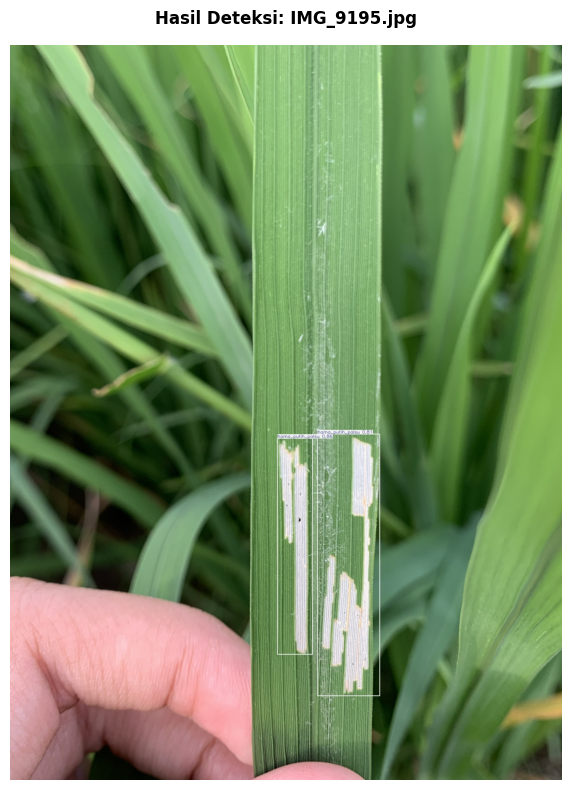


 Laporan Hasil Deteksi:
----------------------------------------
hama_putih_palsu          (Confidence: 85.71%)
hama_putih_palsu          (Confidence: 80.6%)


In [ ]:
gambar_tes = 'IMG_9195.jpg'

if not os.path.exists(gambar_tes):
    print(f"File '{gambar_tes}' tidak ditemukan di /content/")
    print("Upload file gambar terlebih dahulu, lalu jalankan ulang cell ini.")
else:
    print(f"Menganalisis gambar: {gambar_tes}\n")


    hasil_prediksi = model_terbaik.predict(
        source     = gambar_tes,
        save       = True,
        conf       = 0.40,
        line_width = 2
    )

    folder_simpan = hasil_prediksi[0].save_dir
    nama_file_asli = os.path.basename(gambar_tes)
    hasil_akhir = os.path.join(folder_simpan, nama_file_asli)

    # Tampilkan gambar hasil prediksi
    if os.path.exists(hasil_akhir):
        img = mpimg.imread(hasil_akhir)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Hasil Deteksi: {gambar_tes}", fontsize=12, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()

    # Tampilkan laporan teks hasil deteksi
    print("\n Laporan Hasil Deteksi:")
    print("-" * 40)
    if len(hasil_prediksi[0].boxes) == 0:
        print("Tidak ada objek terdeteksi dengan confidence ≥ 40%.")
        print("Coba turunkan nilai 'conf' atau gunakan gambar yang lebih jelas.")
    else:
        for kotak in hasil_prediksi[0].boxes:
            akurasi   = round(kotak.conf[0].item() * 100, 2)
            id_kelas  = int(kotak.cls[0].item())
            nama_kelas = model_terbaik.names[id_kelas]
            print(f"{nama_kelas:<25} (Confidence: {akurasi}%)")

---
## **7. EKSPOR DAN PENGAMANAN MODEL**
Menyimpan model ke berbagai format dan mengamankannya ke Google Drive

### 7.1 Unduh Model PyTorch (.pt)

In [ ]:
pt_path = os.path.join(base_path, 'weights/best.pt')
print("Mengunduh model best.pt")
files.download(pt_path)
print("best.pt berhasil diunduh.")

Mengunduh model best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

best.pt berhasil diunduh.


### 7.2 Ekspor ke Format ONNX

In [ ]:
print("Mengekspor model ke format ONNX...")

# Load ulang model terbaik
onnx_path = model_untuk_ekspor.export(format='onnx')

print(f"Ekspor selesai! File ONNX tersimpan di: {onnx_path}")
files.download(str(onnx_path))
print("best.onnx berhasil diunduh.")

Mengekspor model ke format ONNX...
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from 'runs/detect/train_project_TA_padi_empat_kelas/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 189ms
Prepared 4 packages in 3.17s
Installed 4 packages in 314ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 4.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

best.onnx berhasil diunduh.


### 7.3 Arsipkan Seluruh Hasil Training

In [ ]:
zip_path = '/content/train_project_TA_padi_empat_kelas.zip'
source_folder = base_path.rstrip('/')

!zip -r '{zip_path}' '{source_folder}/'
files.download(zip_path)
print("ZIP arsip berhasil diunduh.")

  adding: runs/detect/train_project_TA_padi_empat_kelas/ (stored 0%)
  adding: runs/detect/train_project_TA_padi_empat_kelas/labels.jpg (deflated 41%)
  adding: runs/detect/train_project_TA_padi_empat_kelas/BoxPR_curve.png (deflated 14%)
  adding: runs/detect/train_project_TA_padi_empat_kelas/confusion_matrix.png (deflated 23%)
  adding: runs/detect/train_project_TA_padi_empat_kelas/BoxF1_curve.png (deflated 9%)
  adding: runs/detect/train_project_TA_padi_empat_kelas/confusion_matrix_normalized.png (deflated 21%)
  adding: runs/detect/train_project_TA_padi_empat_kelas/val_batch0_labels.jpg (deflated 14%)
  adding: runs/detect/train_project_TA_padi_empat_kelas/results.png (deflated 8%)
  adding: runs/detect/train_project_TA_padi_empat_kelas/train_batch0.jpg (deflated 5%)
  adding: runs/detect/train_project_TA_padi_empat_kelas/val_batch0_pred.jpg (deflated 13%)
  adding: runs/detect/train_project_TA_padi_empat_kelas/results.csv (deflated 64%)
  adding: runs/detect/train_project_TA_padi_e

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ZIP arsip berhasil diunduh.


### 7.4 Salin Arsip ke Google Drive

In [ ]:
drive_dest_folder = '/content/drive/MyDrive/Model_Project_TA_Deteksi_Penyakit_Hama_Padi/'
drive_dest_path   = drive_dest_folder + 'train_project_TA_padi_empat_kelas.zip'

os.makedirs(drive_dest_folder, exist_ok=True)
shutil.copy(zip_path, drive_dest_path)

print(f"Arsip berhasil disalin ke Google Drive:")
print(f"   {drive_dest_path}")
print("\nSemua file model tersimpan aman. Training selesai!")

Arsip berhasil disalin ke Google Drive:
   /content/drive/MyDrive/Model_Project_TA_Deteksi_Penyakit_Hama_Padi/train_project_TA_padi_empat_kelas.zip

Semua file model tersimpan aman. Training selesai!
